# Level 4 — 심층 분석: Grad-CAM 및 효율성 Trade-off

**목표**: 모델의 *동작 원리* 를 설명하고, FPS와 정확도의 trade-off 를 정량화합니다.

리포트 필수 산출물:
1. **속성별 정규화 Confusion Matrix 3개** — best 모델 기준.
2. **Grad-CAM 패널** — 같은 이미지에 대해 3개 head 가 각각 어디를 보는지 시각화 (예: `rainy + night + city street` 인 이미지).
3. 모든 백본에 대한 **FPS vs Avg-MF1 Pareto plot**.

본 노트북은 학습 노트북이 아니라 분석 노트북이지만, wandb 가 활성화되어 있으면 confusion matrix 이미지·Grad-CAM 패널·FPS 표를 같은 프로젝트의 별도 Run 으로 업로드합니다.

In [1]:
import os
import sys

repo_url  = "https://github.com/min0712-cdl/HYU-AUE8088-PA2.git"
repo_name = "HYU-AUE8088-PA2"

if not os.path.exists(f"/content/{repo_name}"):
    !git clone {repo_url}
else:
    !git -C /content/{repo_name} pull

%cd /content/{repo_name}

from google.colab import drive
drive.mount("/content/drive")

ARTIFACT_ROOT = os.environ.get("AUE8088_ARTIFACT_ROOT", "/content/drive/MyDrive/AUE8088_PA2")
CHECKPOINT_DIR = os.path.join(ARTIFACT_ROOT, "checkpoints")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

%load_ext autoreload
%autoreload 2

# 의존성 설치 (이미 설치된 패키지는 빠르게 skip)
!pip install -q -r requirements.txt

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.9/274.9 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.8/26.8 MB 94.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 92.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 66.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 22.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.7 MB/s eta 0:00:00:00:0100:01
   ━━━━

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader

from src.utils.seed import set_seed
from src.utils.transforms import eval_transform
from src.utils.metrics import collect_predictions, evaluation_report, print_evaluation_report, CLASS_NAMES
from src.utils.efficiency import measure_fps
from src.utils.wandb_logger import WandbLogger
from src.datasets.bdd_attr import BDDAttrDataset, ATTRIBUTES, NUM_CLASSES
from src.xai.gradcam import GradCAM
from src.models.vgg import VGG16
from src.models.resnet import resnet18, resnet50
from src.models.vit import vit_small_patch16_224

set_seed(42, deterministic=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
USE_WANDB = os.environ.get("AUE8088_USE_WANDB", "0") == "1"
if USE_WANDB:
    import wandb
    wandb.login()

WANDB_PROJECT = "aue8088-pa2" if USE_WANDB else None
logger = WandbLogger(project=WANDB_PROJECT, run_name="level4-analysis", tags=["level4", "analysis"])

In [4]:
# --- 데이터셋 자동 다운로드 (Google Drive) ---------------------------------
# ../data/set_a 가 없으면 zip 을 받아 상위 폴더에 압축 해제 → ../data/set_a, ../data/set_b 생성.
import os, sys, zipfile, subprocess

GDRIVE_FILE_ID = "1L7YC70QlO87aIbE5lbtQ94HUINJijBKK"
ZIP_PATH   = "../aue8088_pa2_data.zip"
EXTRACT_TO = ".."   # zip 내부 최상위가 data/ 이므로 상위 폴더에 풀면 ../data/... 가 됨
DATA_ROOT = "../data/set_a"

if not os.path.isdir(DATA_ROOT):
    try:
        import gdown
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
        import gdown

    if not os.path.exists(ZIP_PATH):
        print("데이터셋 zip 다운로드 중...")
        gdown.download(id=GDRIVE_FILE_ID, output=ZIP_PATH, quiet=False)

    print("압축 해제 중...")
    with zipfile.ZipFile(ZIP_PATH) as zf:
        zf.extractall(EXTRACT_TO)
    print(f"완료 → {DATA_ROOT}")
else:
    print(f"데이터셋이 이미 존재합니다 → {DATA_ROOT}")
# --------------------------------------------------------------------------

# Level 3에서 선택된 best ViT-S 모델 로드.
val_ds = BDDAttrDataset("../data/set_a", "val", transform=eval_transform())
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=2)

model = vit_small_patch16_224().to(device)
ckpt = torch.load(os.path.join(CHECKPOINT_DIR, "level3_best.pth"), map_location=device)
model.load_state_dict(ckpt["state_dict"])
model.eval()
print(
    f"Loaded {ckpt.get('backbone', 'vit_s16_pretrained')} "
    f"from Level 3 experiment: {ckpt.get('experiment', {})}"
)

데이터셋 zip 다운로드 중...


Downloading...
From (original): https://drive.google.com/uc?id=1L7YC70QlO87aIbE5lbtQ94HUINJijBKK
From (redirected): https://drive.google.com/uc?id=1L7YC70QlO87aIbE5lbtQ94HUINJijBKK&confirm=t&uuid=6ce88b8c-496c-4f97-9e2c-d7454bf9fdb4
To: /content/aue8088_pa2_data.zip
100%|██████████| 243M/243M [00:02<00:00, 110MB/s]  


압축 해제 중...
완료 → ../data/set_a
Loaded vit_s16_pretrained from Level 3 experiment: {'name': 'mixup-cutmix-only', 'use_sampler': False, 'use_mix': True}


/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/u

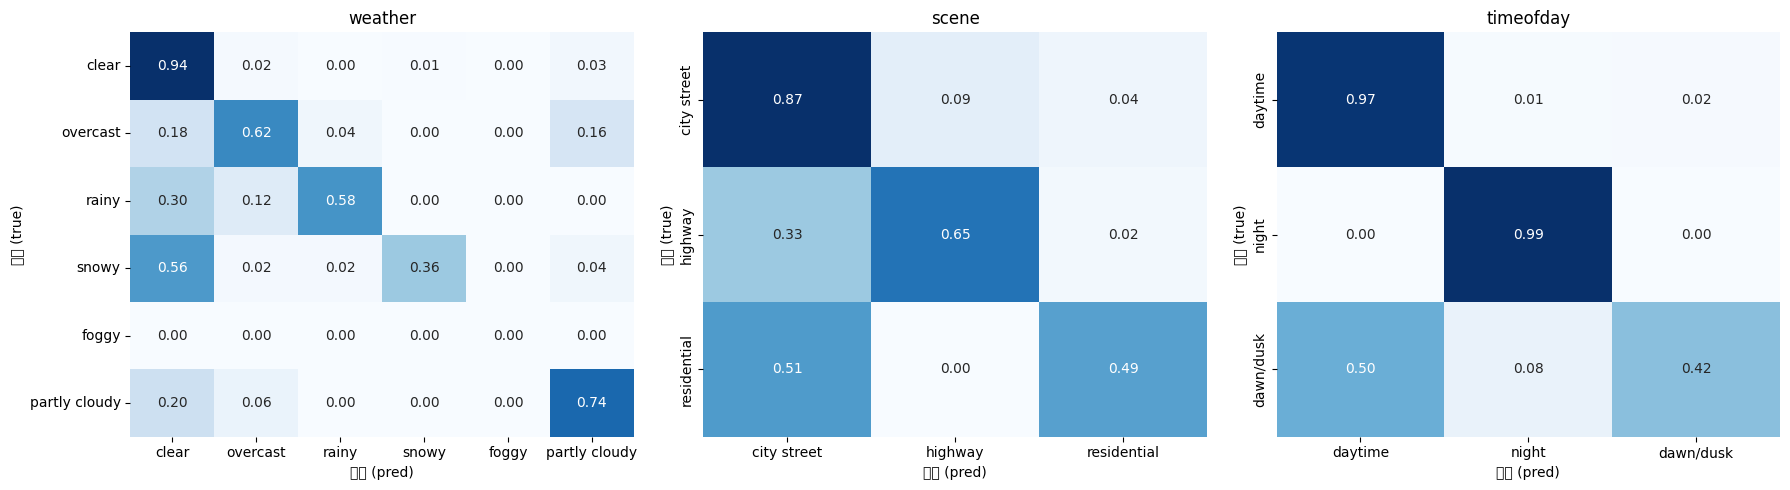

In [5]:
# 속성별 정규화 Confusion Matrix 생성 및 시각화
preds, probs, targets, _ = collect_predictions(model, val_loader, device)
report = evaluation_report(preds, probs, targets)
print_evaluation_report(report, title="Level 4 - Level 3 best model")
logger.log_evaluation("analysis", report)
cms = report["confusion_matrices"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, a in zip(axes, ATTRIBUTES):
    sns.heatmap(cms[a], annot=True, fmt=".2f", cmap="Blues", ax=ax, cbar=False,
                xticklabels=CLASS_NAMES[a], yticklabels=CLASS_NAMES[a])
    ax.set_title(f"{a}")
    ax.set_xlabel("예측 (pred)"); ax.set_ylabel("정답 (true)")
fig.tight_layout()
logger.log_image("analysis/confusion_matrices", fig)
plt.show()

# 속성별 개별 confusion matrix 도 분리해서 업로드
for a in ATTRIBUTES:
    logger.log_confusion_matrix(f"analysis/cm_{a}", cms[a], CLASS_NAMES[a])

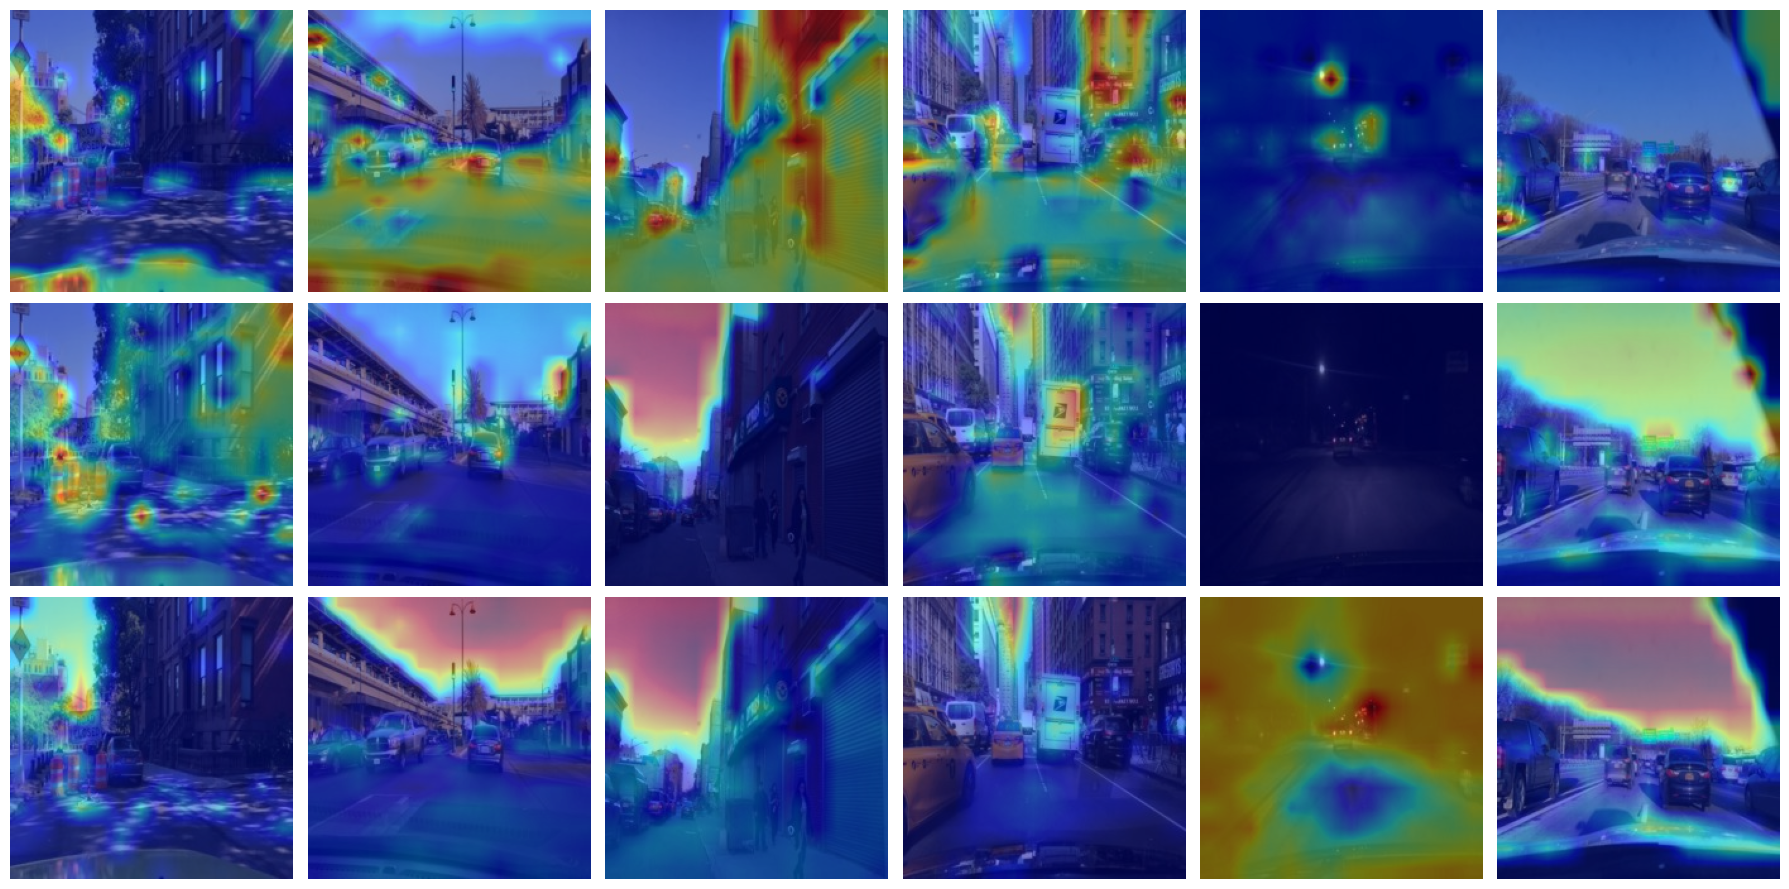

In [6]:
# ViT patch embedding의 14x14 feature map을 target layer로 사용.
target_layer = model.patch_embed.proj
gc = GradCAM(model, target_layer)

batch = next(iter(val_loader))
x = batch["image"][:6].to(device)  # 샘플 이미지 6장

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
for row, attr in enumerate(ATTRIBUTES):
    # 각 속성 head 의 최대 logit 합을 score 로 사용 → 해당 head 가 "보는" 영역 추출
    cam = gc(x, lambda out, a=attr: out[a].max(dim=-1).values.sum())
    for col in range(6):
        img = x[col].cpu().permute(1, 2, 0).numpy()
        img = (img - img.min()) / (img.max() - img.min())
        axes[row, col].imshow(img)
        axes[row, col].imshow(cam[col].cpu().numpy(), cmap="jet", alpha=0.45)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(attr, fontsize=14)
fig.tight_layout()
logger.log_image("analysis/gradcam_panel", fig)
plt.show()

VGG16        FPS = 108.41
ResNet-18    FPS = 264.65
ResNet-50    FPS = 128.77
ViT-S        FPS = 135.86


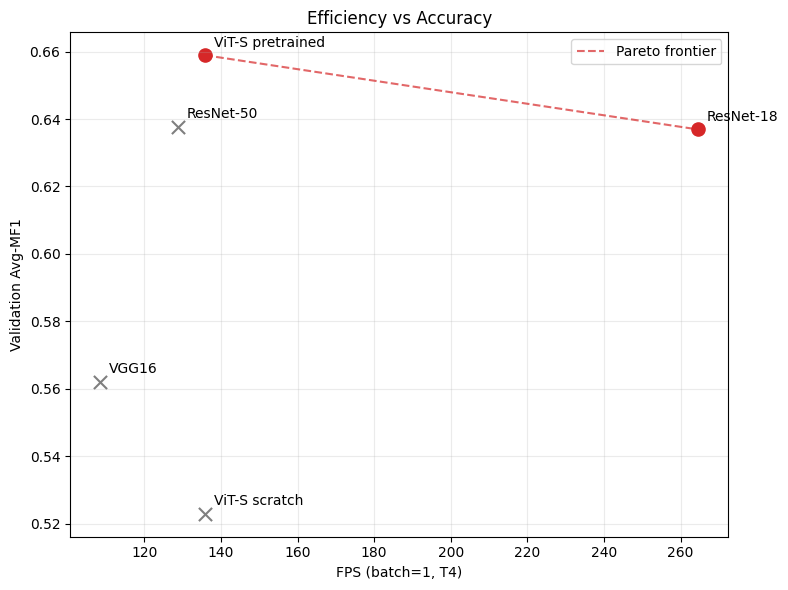

In [7]:
# FPS 측정 전 XAI 모델의 GPU 메모리를 반환.
del gc
model = model.cpu()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# FPS 측정 — 배치 1, 224x224, warm-up 20회 후 200회 평균.
model_fns = {
    "VGG16": VGG16,
    "ResNet-18": resnet18,
    "ResNet-50": resnet50,
    "ViT-S": vit_small_patch16_224,
}
checkpoint_specs = {
    "VGG16": (VGG16, "level1_vgg16.pth"),
    "ResNet-18": (resnet18, "level1_resnet18.pth"),
    "ResNet-50": (resnet50, "level1_resnet50.pth"),
    "ViT-S scratch": (vit_small_patch16_224, "level2_vit_s16_scratch.pth"),
    "ViT-S pretrained": (vit_small_patch16_224, "level2_vit_s16_pretrained.pth"),
}

def checkpoint_state(payload):
    return payload["state_dict"] if isinstance(payload, dict) and "state_dict" in payload else payload

avg_mf1 = {}
for name, (model_fn, filename) in checkpoint_specs.items():
    evaluated_model = model_fn().to(device)
    payload = torch.load(os.path.join(CHECKPOINT_DIR, filename), map_location="cpu")
    evaluated_model.load_state_dict(checkpoint_state(payload))
    eval_preds, eval_probs, eval_targets, _ = collect_predictions(evaluated_model, val_loader, device)
    eval_report = evaluation_report(eval_preds, eval_probs, eval_targets)
    avg_mf1[name] = eval_report["avg_macro_f1"]
    print(f"{name:16s} validation Avg-MF1 = {avg_mf1[name]:.5f}")
    del evaluated_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

fps_by_arch = {}
for name, fn in model_fns.items():
    measured_model = fn().to(device).eval()
    fps = measure_fps(measured_model, device, batch_size=1, n_warmup=20, n_iter=200)
    fps_by_arch[name] = fps
    print(f"{name:12s} FPS = {fps:.2f}")
    del measured_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

fps_rows = [
    ["VGG16", round(fps_by_arch["VGG16"], 2), avg_mf1["VGG16"]],
    ["ResNet-18", round(fps_by_arch["ResNet-18"], 2), avg_mf1["ResNet-18"]],
    ["ResNet-50", round(fps_by_arch["ResNet-50"], 2), avg_mf1["ResNet-50"]],
    ["ViT-S scratch", round(fps_by_arch["ViT-S"], 2), avg_mf1["ViT-S scratch"]],
    ["ViT-S pretrained", round(fps_by_arch["ViT-S"], 2), avg_mf1["ViT-S pretrained"]],
]
logger.log_table("analysis/fps_accuracy", ["backbone", "FPS", "Avg-MF1"], fps_rows)

# TODO: 모든 백본에 대해 FPS (x축) vs Avg-MF1 (y축) Pareto plot 을 작성하세요.
points = [(row[0], row[1], row[2]) for row in fps_rows]
pareto = []
for name, fps, score in points:
    dominated = any(
        other_fps >= fps and other_score >= score
        and (other_fps > fps or other_score > score)
        for other_name, other_fps, other_score in points if other_name != name
    )
    if not dominated:
        pareto.append((name, fps, score))

fig, ax = plt.subplots(figsize=(8, 6))
for name, fps, score in points:
    is_pareto = any(item[0] == name for item in pareto)
    ax.scatter(fps, score, s=90, marker="o" if is_pareto else "x",
               color="tab:red" if is_pareto else "tab:gray")
    ax.annotate(name, (fps, score), xytext=(6, 6), textcoords="offset points")

pareto_sorted = sorted(pareto, key=lambda item: item[1])
ax.plot([item[1] for item in pareto_sorted], [item[2] for item in pareto_sorted],
        color="tab:red", linestyle="--", alpha=0.7, label="Pareto frontier")
ax.set_xlabel("FPS (batch=1, T4)")
ax.set_ylabel("Validation Avg-MF1")
ax.set_title("Efficiency vs Accuracy")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
logger.log_image("analysis/pareto", fig)
plt.show()

In [8]:
logger.finish()